In [2]:
import pandas as pd
df=pd.read_csv(r"D:\Machine_Learning_Journey\Streamlit\startup_funding.csv")
df

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"


In [3]:
list(df['Startup Name'].unique())

['BYJU’S',
 'Shuttl',
 'Mamaearth',
 'https://www.wealthbucket.in/',
 'Fashor',
 'Pando',
 'Zomato',
 'Ecozen',
 'CarDekho',
 'Dhruva Space',
 'Rivigo',
 'Healthians',
 'Licious',
 'InCred',
 'Trell',
 'Rein Games',
 'Lenskart.com',
 'Freshworks',
 'Misters',
 'Sunstone Eduversity Pvt. Ltd',
 'Burger Singh',
 'Ninjacart',
 'Aye Finance',
 'SuperGaming',
 'Clumio',
 'eBikeGo',
 'Digital Mall Asia',
 'Medikabazaar',
 'Vogo Automotive',
 'Furtados School of Music',
 'Paytm',
 'Dunzo',
 'Udaan',
 'The Man Company',
 'FPL Technologies',
 'Cashflo',
 'Digital F5',
 '3rdFlix',
 '75F',
 'Myelin Foundry',
 'Atomberg Technology',
 'GOQii',
 'Vyapar App',
 'Progcap',
 'MyPetrolPump',
 'Alteria Capital',
 'Pine Labs',
 'Meesho',
 'Cars24',
 'Uniphore',
 'Zendrive',
 'Lo! Foods',
 'Tala',
 'INDwealth',
 'HungerBox',
 'AdmitKard',
 'Mishry Reviews',
 'Grofers',
 'Rapido Bike Taxi',
 'RenewBuy',
 'Atlan',
 'WizCounsel',
 'Ola Cabs',
 'Daalchini Technologies',
 '"BYJU\\\\\'S"',
 'Moglix',
 'Ezyhaul',


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [5]:
df['Startup Name'].shape

(3044,)

In [6]:
df.drop(columns=['Remarks'],inplace=True)

In [7]:
df.set_index('Sr No',inplace=True)

In [8]:
df.rename(columns={
    'Date dd/mm/yyyy':'date',
    'Startup Name':'startup',
    'Industry Vertical':'vertical',
    'SubVertical':'subvertical',
    'City  Location':'city',
    'Investors Name':'investors',
    'InvestmentnType':'round',
    'Amount in USD':'amount'
    
    
    
    
    
    
    
},inplace=True)

In [9]:
#0=the amount is disclosed
df['amount']=df['amount'].fillna('0')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3044 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         3044 non-null   object
 1   startup      3044 non-null   object
 2   vertical     2873 non-null   object
 3   subvertical  2108 non-null   object
 4   city         2864 non-null   object
 5   investors    3020 non-null   object
 6   round        3040 non-null   object
 7   amount       3044 non-null   object
dtypes: object(8)
memory usage: 214.0+ KB


In [11]:
df['amount']=df['amount'].str.replace(',','')
df['amount']=df['amount'].str.replace('undisclosed','0')
df['amount']=df['amount'].str.replace('unknown','0')
df['amount']=df['amount'].str.replace('Undisclosed','0')

In [12]:
df=df[df['amount'].str.isdigit()]

In [13]:
df['amount']=df['amount'].astype('float')

C:\Users\mohds\AppData\Local\Temp\ipykernel_7900\3595834934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount']=df['amount'].astype('float')


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3029 non-null   object 
 1   startup      3029 non-null   object 
 2   vertical     2858 non-null   object 
 3   subvertical  2104 non-null   object 
 4   city         2849 non-null   object 
 5   investors    3005 non-null   object 
 6   round        3027 non-null   object 
 7   amount       3029 non-null   float64
dtypes: float64(1), object(7)
memory usage: 213.0+ KB


In [15]:
def to_inr(dollar):
    inr=dollar*82.5
    return inr/10000000
df['amount']=df['amount'].apply(to_inr)

C:\Users\mohds\AppData\Local\Temp\ipykernel_7900\3365512168.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount']=df['amount'].apply(to_inr)


In [16]:
df

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000
...,...,...,...,...,...,...,...,...
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,37.125000
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,6.806250
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,12.375000


In [17]:
df['date']=df['date'].str.replace('05/072018','05/07/2018')

C:\Users\mohds\AppData\Local\Temp\ipykernel_7900\906737603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']=df['date'].str.replace('05/072018','05/07/2018')


In [18]:
df['date']=pd.to_datetime(df['date'],errors='coerce')

C:\Users\mohds\AppData\Local\Temp\ipykernel_7900\3169875093.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']=pd.to_datetime(df['date'],errors='coerce')


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1284 non-null   datetime64[ns]
 1   startup      3029 non-null   object        
 2   vertical     2858 non-null   object        
 3   subvertical  2104 non-null   object        
 4   city         2849 non-null   object        
 5   investors    3005 non-null   object        
 6   round        3027 non-null   object        
 7   amount       3029 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 213.0+ KB


In [20]:
df['date'].dt.day

Sr No
1       1.0
2       NaN
3       1.0
4       1.0
5       1.0
       ... 
3040    NaN
3041    NaN
3042    NaN
3043    NaN
3044    NaN
Name: date, Length: 3029, dtype: float64

In [21]:
df=df.dropna(subset=['date','startup','vertical','city','investors','round','amount'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1203 entries, 1 to 2829
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1203 non-null   datetime64[ns]
 1   startup      1203 non-null   object        
 2   vertical     1203 non-null   object        
 3   subvertical  891 non-null    object        
 4   city         1203 non-null   object        
 5   investors    1203 non-null   object        
 6   round        1203 non-null   object        
 7   amount       1203 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 84.6+ KB


In [23]:
sorted(set(df['investors'].str.split(',').sum()))

['',
 ' & Others',
 ' 500 Start-Ups',
 ' 500 Startups',
 ' 91springboard',
 ' ABCOM Investments',
 ' AECAL',
 ' AET Fund',
 ' ASP Consulting',
 ' AVN Business Solutions',
 ' Aarin Capital',
 ' Aarin Capital & Others',
 ' Aaruha Technology Fund',
 ' Abaran Deep',
 ' Abhai S. Rao',
 ' Abhay Singhal',
 ' Abhinav Patodia',
 ' Abhishek Goyal',
 ' Abhishek Gupta',
 ' Abhishekh Goyal',
 ' Abstract Ventures',
 ' Accel India',
 ' Accel Partners',
 ' Accel Partners & Others',
 ' Accel Partners and G Raghunandan',
 ' Accel Partners and IDG Ventures',
 ' Accel Partners and Saama Capital',
 ' Accion',
 ' Adam D\\\\xe2\\\\x80\\\\x99Angelo',
 ' Aditya Agarwal',
 ' Aditya Aggarwal',
 ' Aditya Malik & Others',
 ' Aditya Vazirani',
 ' AdvantEdge Partners',
 ' Adveq Management',
 ' Aijaz Saleem',
 ' Ajay Bhatia',
 ' Ajeet Khurana & others',
 ' Akatsuki and Incubate Fund from Japan and Better Capital AngelList syndicate.',
 ' Alfa Capital',
 ' Alok Divatia',
 ' Alok Mittal',
 ' Alok Sharma',
 ' Aloke Bajp

In [24]:
df.to_csv('startup_cleaned.csv',index=False)

In [25]:
df[df['investors'].str.contains('IDG Ventures')].head()[['date','startup','vertical','city','round','amount']]

,date,startup,vertical,city,round,amount
Sr No,,,,,,
259,2018-02-05,Bizongo,Consumer Internet,Mumbai,Private Equity,181.500
439,2017-07-12,eShakti,Ecommerce,Chennai,Debt Funding,18.975
478,2017-04-11,Hevo Data,Technology,Bangalore,Private Equity,8.250
479,2017-06-11,Smart Karma,Technology,Bangalore,Private Equity,0.000
490,2017-09-11,Mobiliz AR,Technology,Bangalore,Private Equity,0.000


In [26]:
df[df['investors'].str.contains('IDG Ventures')].groupby('startup')['amount'].sum().sort_values(ascending=False) 

startup
Lenskart                 495.0000
Bizongo                  206.2500
Curefit                  123.7500
Fintellix                123.7500
Xpressbees               103.1250
FirstCry.com              82.5000
HealthifyMe               49.5000
Blowhorn                  30.1125
eShakti                   18.9750
POPxo.com                 16.5000
Uniphore                  16.5000
Hansel.io                 11.1375
Little Black Book          8.2500
Cloudcherry Analytics      8.2500
Hevo Data                  8.2500
CityFlo                    6.1875
Tripoto                    0.0000
Smart Karma                0.0000
Mobiliz AR                 0.0000
Unbxd                      0.0000
Name: amount, dtype: float64

<Axes: ylabel='amount'>

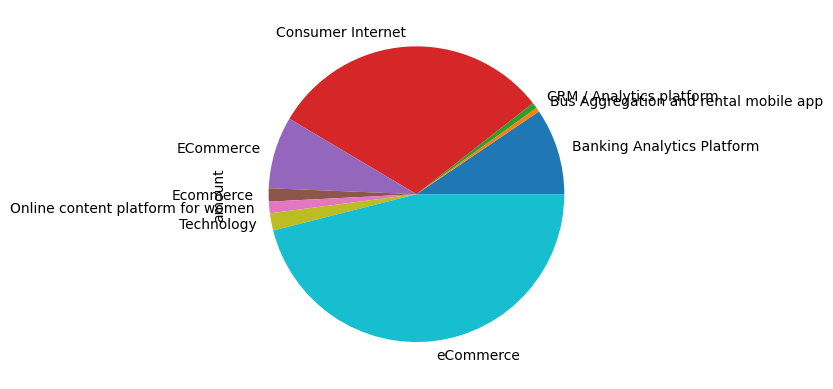

In [27]:
df[df['investors'].str.contains('IDG Ventures')].groupby('vertical')['amount'].sum().plot(kind='pie')

In [28]:
df['year']=df['date'].dt.year

C:\Users\mohds\AppData\Local\Temp\ipykernel_7900\2063528821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year']=df['date'].dt.year


In [29]:
df

,date,startup,vertical,subvertical,city,investors,round,amount,year
Sr No,,,,,,,,,
1,2020-09-01,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
3,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-02-01,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020
7,2020-10-01,Zomato,Hospitality,Online Food Delivery Platform,Gurgaon,Ant Financial,Private Equity Round,1237.500000,2020
...,...,...,...,...,...,...,...,...,...
2825,2015-09-04,Urban Ladder,Online Furnishing\\neCommerce,NaN,Bangalore,"Sequoia Capital, TR Capital, Steadview Capital...",Private Equity,412.500000,2015
2826,2015-09-04,Purple Squirrel,Ed-Tech,NaN,Mumbai,"Matrix Partners India, India Quotient",Private Equity,0.000000,2015
2827,2015-10-04,Whatfix,Interactive\\xc2\\xa0 How-To Guides,NaN,Bangalore,"Helion Venture Partner, Powerhouse Ventures, G...",Seed Funding,7.425000,2015


<Axes: xlabel='year'>

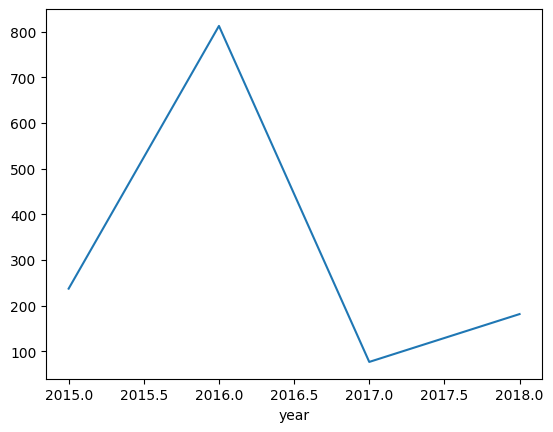

In [30]:
df[df['investors'].str.contains('IDG Ventures')].groupby('year')['amount'].sum().plot()

In [31]:
df.to_csv('cleaned.csv')

In [32]:
round(df['amount'].sum()

SyntaxError: incomplete input (1490109790.py, line 1)

In [ ]:

df.groupby('startup')['amount'].sum().mean()

np.float64(113.5404834004159)

In [ ]:
df['month']=df['date'].dt.month

C:\Users\mohds\AppData\Local\Temp\ipykernel_24896\4289079944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month']=df['date'].dt.month


In [ ]:
temp_df=df.groupby(['year','month'])['startup'].count().reset_index()

In [ ]:
temp_df['x_axis']=temp_df['month'].astype('str')+'-'+temp_df['year'].astype('str')

In [ ]:
temp_df['x_axis']

0      1-2015
1      2-2015
2      3-2015
3      4-2015
4      5-2015
       ...   
57    11-2019
58    12-2019
59     2-2020
60     9-2020
61    10-2020
Name: x_axis, Length: 62, dtype: object

In [ ]:
df.groupby(['year','month'])['amount'].sum().reset_index()

,year,month,amount
0,2015,1,5274.637500
1,2015,2,1567.178250
2,2015,3,1910.658750
3,2015,4,1936.646250
4,2015,5,817.863750
...,...,...,...
57,2019,11,1153.350000
58,2019,12,1233.375000
59,2020,2,39.600000
60,2020,9,1801.460595


In [54]:
sectors=df.groupby('vertical') 
sectors['amount'].sum().sort_values(ascending=False).reset_index().head(3)

,vertical,amount
0,Consumer Internet,25187.402625
1,eCommerce,22949.883000
2,Technology,6381.825450


In [53]:
df.groupby('city')['amount'].sum().sort_values(ascending=False).reset_index()

,city,amount
0,Bangalore,39224.340375
1,Bengaluru,20720.688904
2,Mumbai,15016.730974
3,Gurgaon,12859.592625
4,New Delhi,11564.264250
...,...,...
69,Siliguri,0.000000
70,US,0.000000
71,Trivandrum,0.000000
72,Udupi,0.000000


In [96]:
start=df.groupby(['year','startup'])['amount'].agg(Total_Funding='sum').sort_values(by='year').reset_index()

year_wise_ana=start.loc[start.groupby('year')['Total_Funding'].idxmax()].reset_index(drop=True)
year_wise_ana
 

,year,startup,Total_Funding
0,2015,Snapdeal,4125.00
1,2016,MakeMyTrip,1485.00
2,2017,Flipkart,20625.00
3,2018,BigBasket,2475.00
4,2019,Udaan,4826.25
5,2020,BYJU’S,1650.00


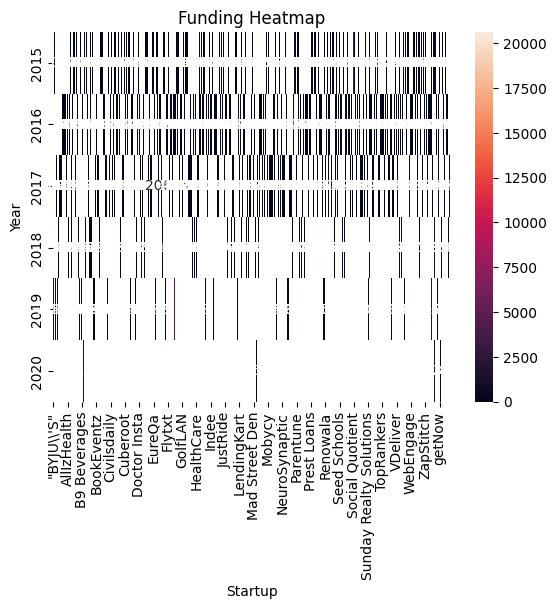

In [98]:
heatmap_data = start.pivot(
    index='year',
    columns='startup',
    values='Total_Funding'
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(heatmap_data, annot=True, fmt='.0f')

plt.title('Funding Heatmap')
plt.xlabel('Startup')
plt.ylabel('Year')
plt.show()